In [5]:
import xarray as xr
import numpy as np
from scipy.signal import periodogram

ds = xr.open_dataset("3harmean/mslprm3harmean.nc")
da = ds["mslprm3harmean"]

print(da)
print("NaN:", np.isnan(da).sum().item())
print("Mean:", da.mean().item())
print("Std:", da.std().item())
print("Min:", da.min().item())
print("Max:", da.max().item())

# cek klimatologi harian setelah harmonik dibuang
ts = da.mean(["lat", "lon"])
clim = ts.groupby("time.dayofyear").mean()

print("Daily clim min:", clim.min().item())
print("Daily clim max:", clim.max().item())
print("Daily clim std:", clim.std().item())

# cek spektrum
f, P = periodogram(ts.values, fs=1.0)
period = 1 / f[1:]
power = P[1:]

for target in [365, 182.5, 121.7]:
    idx = np.argmin(abs(period - target))
    print(target, "hari power:", power[idx])

<xarray.DataArray 'mslprm3harmean' (time: 17167, lat: 48, lon: 64)> Size: 211MB
[52737024 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 137kB 1979-01-01 1979-01-02 ... 2025-12-31
  * lat      (lat) float32 192B -29.25 -28.0 -26.75 -25.5 ... 27.0 28.25 29.5
  * lon      (lon) float32 256B 75.5 76.75 78.0 79.25 ... 151.8 153.0 154.2
NaN: 0
Mean: 3.8985894207144156e-05
Std: 243.34185791015625
Min: -5011.1328125
Max: 2856.40625
Daily clim min: -40.678253173828125
Daily clim max: 33.9276123046875
Daily clim std: 14.769305229187012
365 hari power: 0.00085971004
182.5 hari power: 0.0003084714
121.7 hari power: 9.064784e-06


In [6]:
ds

<xarray.Dataset> Size: 211MB
Dimensions:         (time: 17167, lat: 48, lon: 64)
Coordinates:
  * time            (time) datetime64[ns] 137kB 1979-01-01 ... 2025-12-31
  * lat             (lat) float32 192B -29.25 -28.0 -26.75 ... 27.0 28.25 29.5
  * lon             (lon) float32 256B 75.5 76.75 78.0 ... 151.8 153.0 154.2
Data variables:
    mslprm3harmean  (time, lat, lon) float32 211MB -500.7 -436.4 ... 78.9 147.5

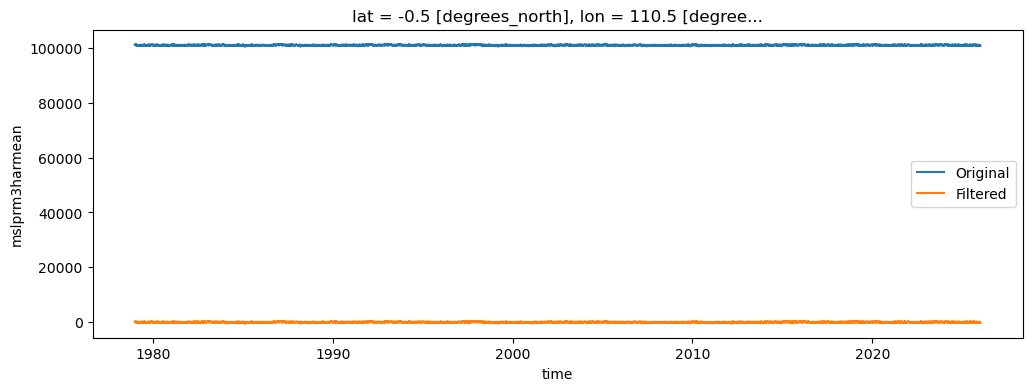

In [9]:
import matplotlib.pyplot as plt
import xarray as xr

# data asli
ori = xr.open_dataset("data_era5_125/mslp_ERA5_1979_2025_1p25deg_ready_ncl.nc")["msl"]

# hasil filter harmonik
fil = xr.open_dataset("3harmean/mslprm3harmean.nc")["mslprm3harmean"]

# pilih satu titik
lat = 0
lon = 110

ori_ts = ori.sel(lat=lat, lon=lon, method="nearest")
fil_ts = fil.sel(lat=lat, lon=lon, method="nearest")

fig, ax = plt.subplots(figsize=(12,4))

ori_ts.plot(ax=ax,label="Original")
fil_ts.plot(ax=ax,label="Filtered")

plt.legend()
plt.show()

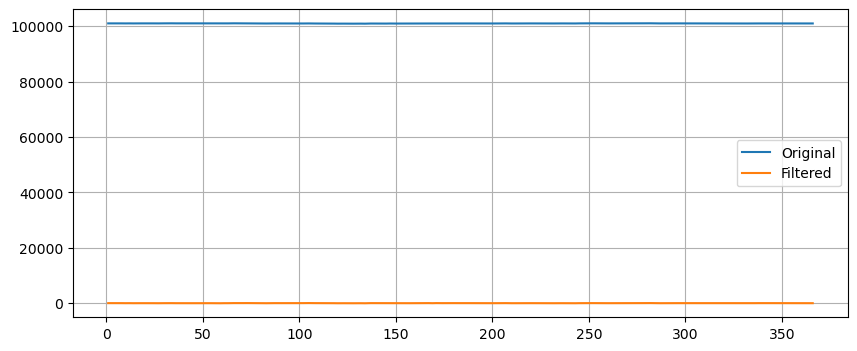

In [11]:
ori_clim = ori_ts.groupby("time.dayofyear").mean()
fil_clim = fil_ts.groupby("time.dayofyear").mean()

plt.figure(figsize=(10,4))
plt.plot(ori_clim.dayofyear, ori_clim, label="Original")
plt.plot(fil_clim.dayofyear, fil_clim, label="Filtered")
plt.grid()
plt.legend()

In [4]:
print("Original std :", ori_ts.std().item())
print("Filtered std :", fil_ts.std().item())

Original std : 2.309673547744751
Filtered std : 1.7874565124511719


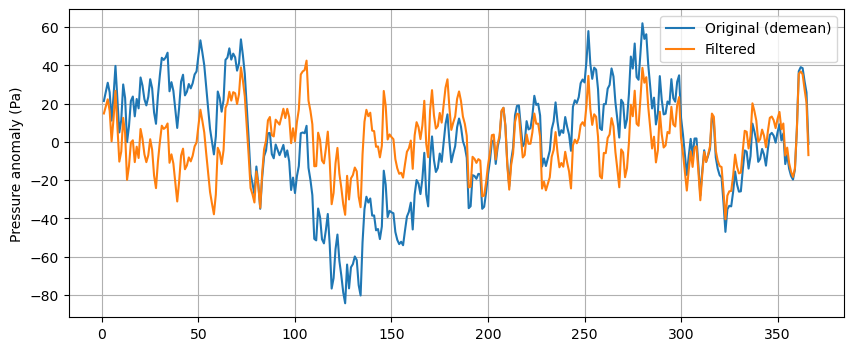

In [12]:
import matplotlib.pyplot as plt

# pilih titik
ori_ts = ori.sel(lat=-0.5, lon=110.5, method="nearest")
fil_ts = fil.sel(lat=-0.5, lon=110.5, method="nearest")

# climatology
ori_clim = ori_ts.groupby("time.dayofyear").mean()
fil_clim = fil_ts.groupby("time.dayofyear").mean()

# hilangkan mean original
ori_clim_anom = ori_clim - ori_clim.mean()

plt.figure(figsize=(10,4))
plt.plot(ori_clim.dayofyear, ori_clim_anom, label="Original (demean)")
plt.plot(fil_clim.dayofyear, fil_clim, label="Filtered")
plt.grid(True)
plt.legend()
plt.ylabel("Pressure anomaly (Pa)")
plt.show()

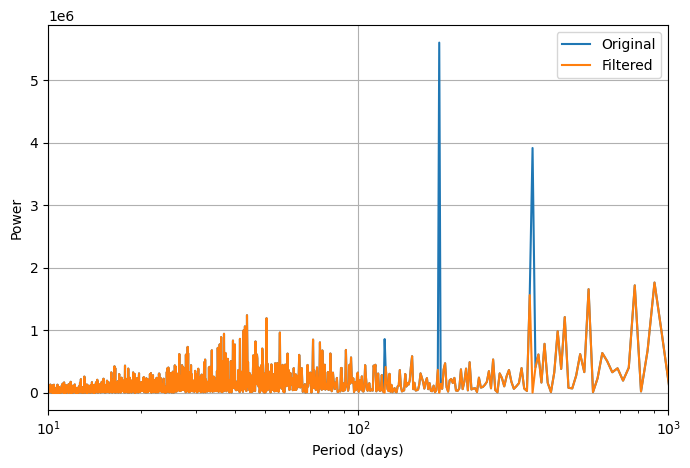

In [13]:
from scipy.signal import periodogram
import matplotlib.pyplot as plt

# Hilangkan mean saja dari original
ori = ori_ts - ori_ts.mean()

f1, P1 = periodogram(ori.values, fs=1.0)
f2, P2 = periodogram(fil_ts.values, fs=1.0)

period1 = 1 / f1[1:]
period2 = 1 / f2[1:]

plt.figure(figsize=(8,5))
plt.semilogx(period1, P1[1:], label="Original")
plt.semilogx(period2, P2[1:], label="Filtered")
plt.xlim(10, 1000)
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.legend()
plt.grid(True)

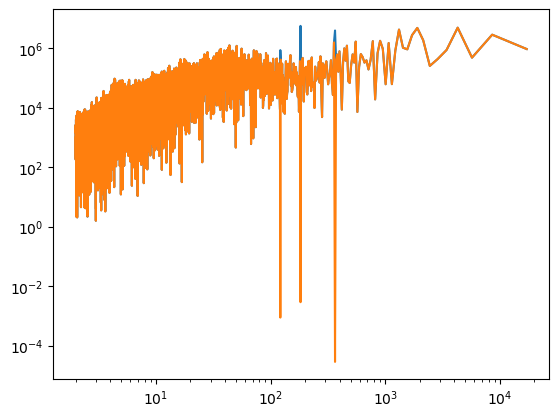

In [14]:
plt.loglog(period1, P1[1:], label="Original")
plt.loglog(period2, P2[1:], label="Filtered")